First 5 rows:
        Date  VIC_stringency  NSW_stringency  VIC_unemployment  \
0 2016-02-01             0.0             0.0          6.186083   
1 2016-03-01             0.0             0.0          5.996102   
2 2016-04-01             0.0             0.0          5.676283   
3 2016-05-01             0.0             0.0          5.684920   
4 2016-06-01             0.0             0.0          5.395598   

   NSW_unemployment  
0          5.624091  
1          5.436768  
2          5.130524  
3          5.034129  
4          5.034800  

Column names:
Index(['Date', 'VIC_stringency', 'NSW_stringency', 'VIC_unemployment',
       'NSW_unemployment'],
      dtype='str')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              121 non-null    datetime64[us]
 1   VIC_stringency    121 non-null    float64       


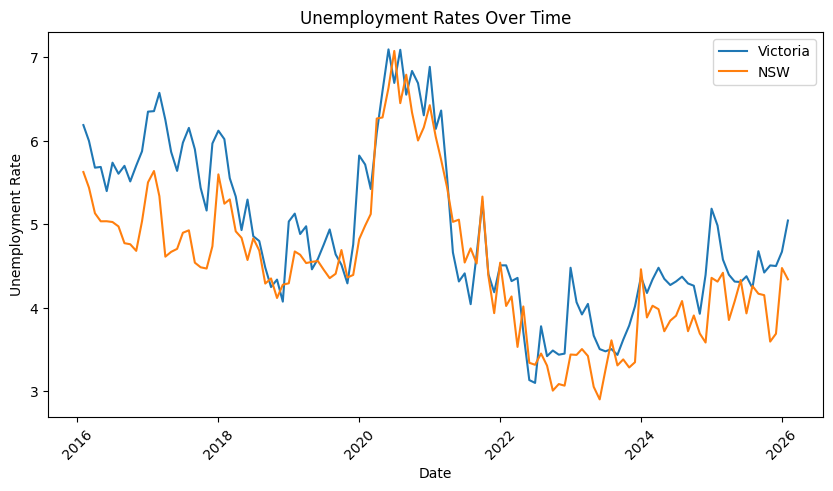


UNEMPLOYMENT RATES OVER TIME
This graph shows how unemployment changed by month in both states. Both spiked during COVID, 
and came down due to government policies. After COVID, the rate moved down to usual levels.



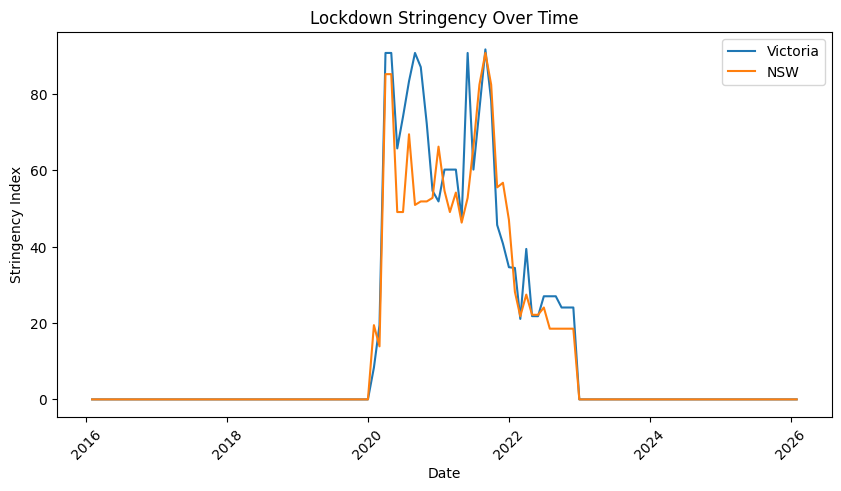


LOCKDOWN STRINGENCY OVER TIME
Shows how strict COVID policies were in VIC and NSW over time.



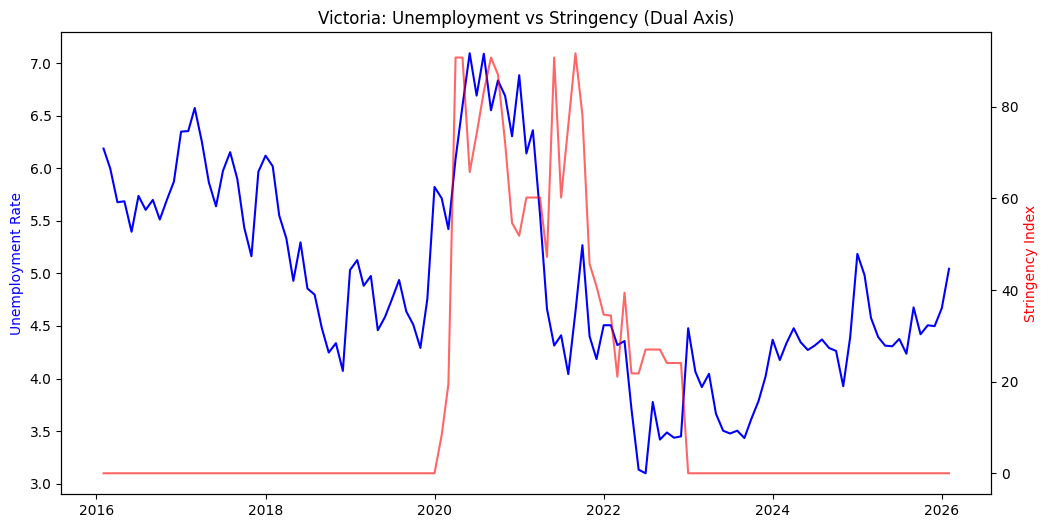

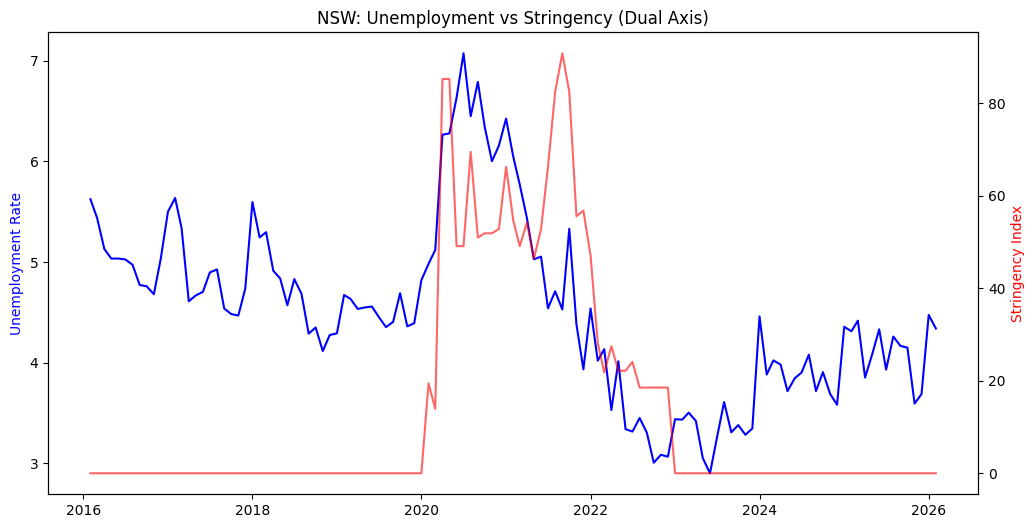


The dual-axis graph allows us to compare how unemployment and stringency moved over time for Victoria and NSW, 
allowing us to see side by side unemployment at a specific time compared to stringency. 
Having both graphs allows us to find patterns such as the massive increase in stringency during COVID, 
and corresponding spike in unemployment. This allows us to witness how the two variables move together, 
and whether they follow similar trends or move differently across states. 
This visualisation acts as an essential first step before any modelling, allowing us to compare between VIC and NSW 
and see if impact lasted longer for a specific state, helping us justify why further analysis is needed 
to get a sense of the underlying dynamics between policy strictness and unemployment over time.



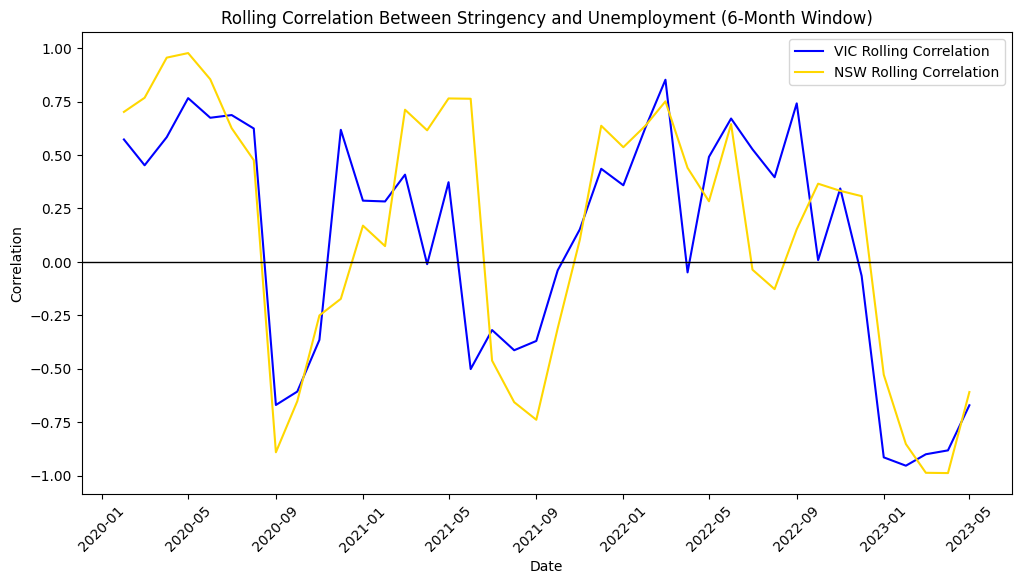


The Rolling Correlation graph allows us to see the relationship between stringency and unemployment over time. 
By having the correlation for both VIC and NSW, we are able to see how correlation differs during specific times, 
especially during COVID. We also notice that over time correlation isn’t constant: it has a sharp increase during 
lockdown periods, showing that with greater stringency, unemployment tended to increase at the same time.

Outside COVID times, the correlation falls closer to zero, showcasing that the relationship weakens with the ease 
of restrictions. This is crucial for our analysis as it demonstrates the impact of lockdown policies is time-varying, 
and not stable. Furthermore, the relationship tends to strengthen only during policy intervention.

This promotes the need for more advanced modelling (like DiD or lagged regressions), as the effect of stringency 
on unemployment is not uniform throughout the timeline and hence requires a more dynamic analysis.



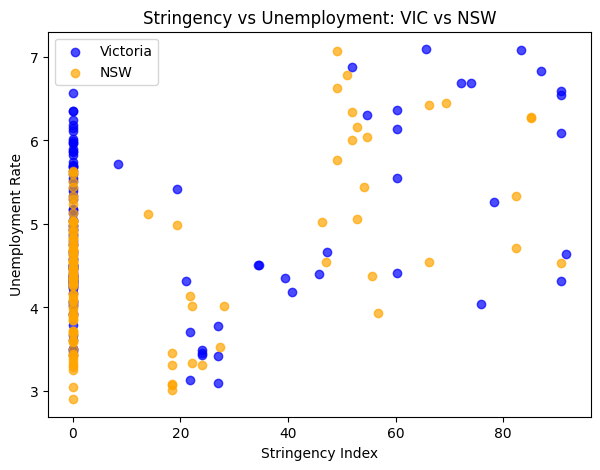


SCATTER PLOT
This scatter plot shows how unemployment varies in VIC and NSW as lockdown stringency changes.
X-axis is stringency index (policy strictness) and Y-axis is VIC and NSW unemployment. Each point is one month. 
There is an observable trend upwards left to right which means higher stringency is associated with higher unemployment; 
but it is not perfectly linear. At high stringency values (pandemic periods), points tend to sit at higher unemployment levels, 
creating a cluster towards the top right of the plot which displays high unemployment correlating with high stringency.



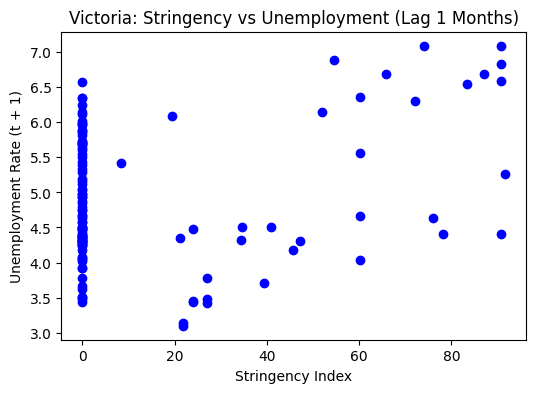

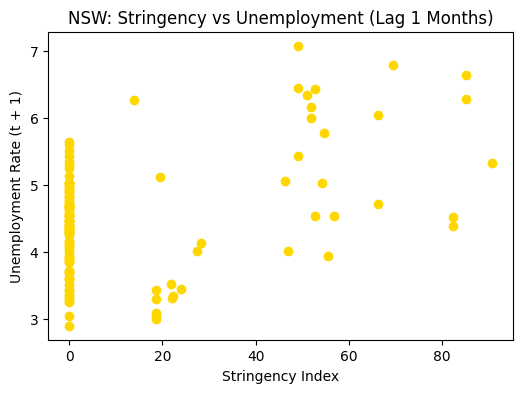

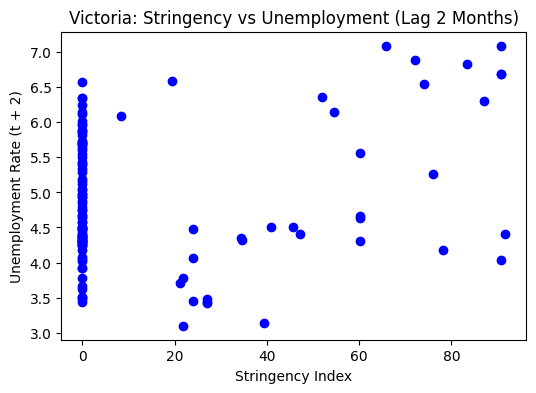

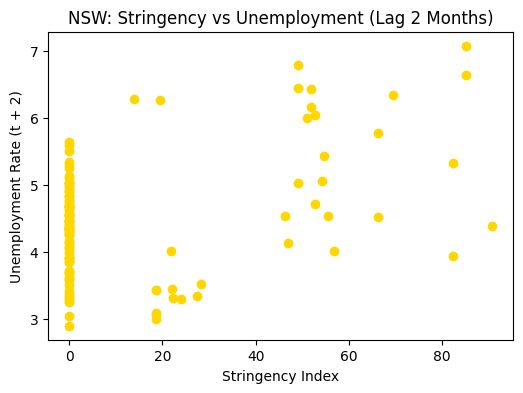

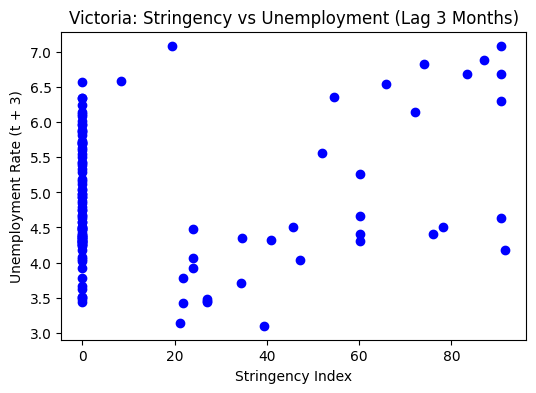

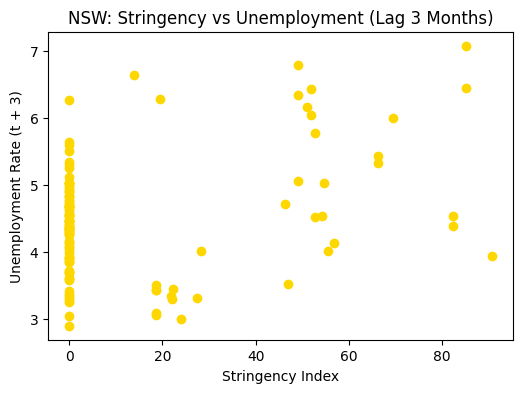


The scatter plots are used to directly assess the relationship between lockdown stringency and unemployment in our dataset. 
Unlike the time-series graphs, they allowed us to isolate the association between these two variables without the influence of time trends, 
which make it easier to observe whether the higher levels of stringency correspond to higher unemployment.

The lagged scatter plots extend this by comparing current stringency with the future unemployment (which is 1-3 months ahead). 
This is important because labour market adjustments are not immediate; businesses respond to restrictions with a delay. 
The clearer relationship which is observed in the lagged plots, especially in Victoria, suggests that lockdown stringency has a delayed effect on unemployment. 
This insight is very valuable for our EDA, because it informs our modelling strategy and it indicates that lagged variables may be necessary 
to accurately predict the causal impact of the lockdown policies.



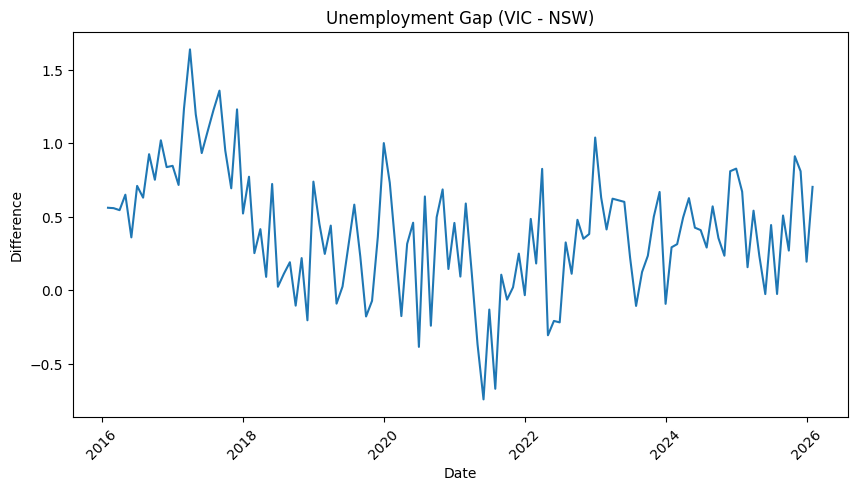


UNEMPLOYMENT GAP
This graph shows the difference between VIC and NSW (VIC minus NSW) unemployment. 
When the line is above zero, unemployment is higher in VIC (which is most of the time during the last 10 years). 
When the line is below zero, unemployment is higher in NSW.



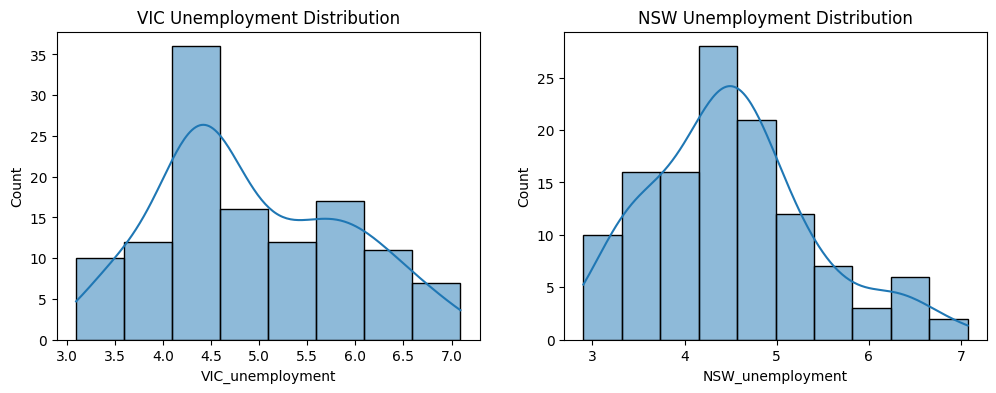


DISTRIBUTION HISTOGRAM
Both VIC and NSW unemployment distributions display a right skew, with most observations concentrated between 4-5% 
and a tail extending toward higher values. The skew is evidently driven by COVID-19 spike in 2020, 
which stretched unemployment to historically high levels for that time period. 
The presence of this skew suggests that a log transformation of the unemployment variable may be worth considering 
in future modelling to reduce the influence of the COVID outlier period on regression estimates.



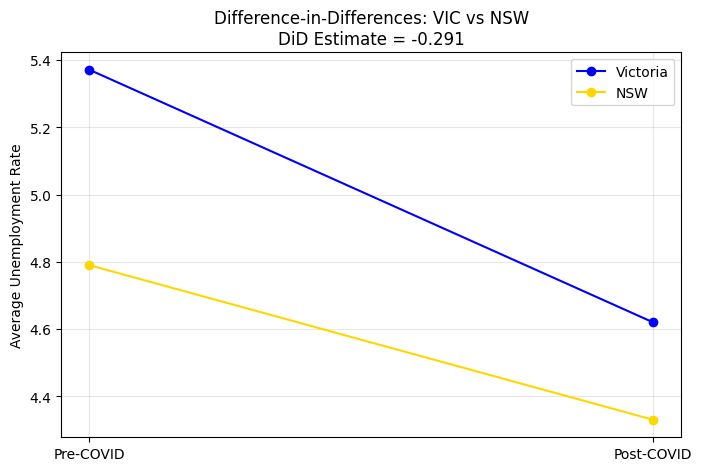

VIC pre-COVID avg: 5.371
VIC post-COVID avg: 4.620
NSW pre-COVID avg: 4.790
NSW post-COVID avg: 4.330
DiD Estimate: -0.291


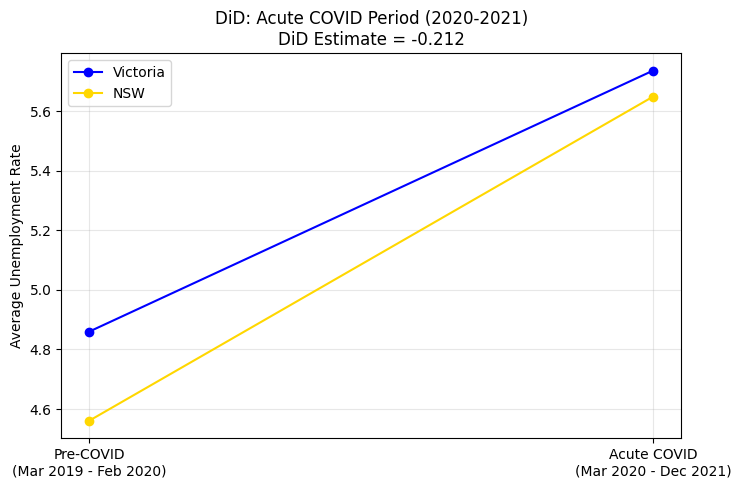

VIC pre-COVID avg: 4.860
VIC acute COVID avg: 5.737
NSW pre-COVID avg: 4.561
NSW acute COVID avg: 5.649
DiD Estimate: -0.212


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('../data/clean/merged_stringency_unemployment.csv')

# Fix column names
df = df.rename(columns={
    'VIC_Unemployment': 'VIC_unemployment',
    'NSW_Unemployment': 'NSW_unemployment',
    'VIC_Stringency': 'VIC_stringency',
    'NSW_Stringency': 'NSW_stringency'
})

# Convert Date BEFORE printing info
df['Date'] = pd.to_datetime(df['Date'])

# =========================
# BASIC DATA INSPECTION
# =========================
print("First 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

print("\nDataset info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("""
The output provides us the structural overview of the dataset before we get into the analysis.
The info() section confirms the 121 monthly observations that we have, without any missing values 
across the five key variables (Date, stringency, and unemployment for both states). This is relevant 
to the assessment as it confirms the completeness and suitability of the time-series analysis without 
needing imputation or cleaning.

Having the table with the first 5 rows allows us to confirm that the data loaded correctly. 
The reason we have only chosen 5 rows is to avoid having convoluted data. We also get a verification 
on the structure: the data is presented in a structured table form, with column consistency, 
correct data types, no missing values, and proper variable alignment.

The summary statistics allow us to get an idea of whether the output analysis confirms what we expect 
to see in the dataset. This helps us gain insight into the spread of the data and the atypically high 
maximum values resulting from the COVID-19 shock. We are able to verify that the effects of COVID are 
clearly visible in the statistics, and that the variables have sufficient variation to support 
econometric modelling later on.
""")

# =========================
# TIME SERIES: UNEMPLOYMENT
# =========================
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['VIC_unemployment'], label='Victoria')
plt.plot(df['Date'], df['NSW_unemployment'], label='NSW')
plt.title('Unemployment Rates Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.legend()
plt.xticks(rotation=45)
plt.show()

print("""
UNEMPLOYMENT RATES OVER TIME
This graph shows how unemployment changed by month in both states. Both spiked during COVID, 
and came down due to government policies. After COVID, the rate moved down to usual levels.
""")

# =========================
# TIME SERIES: STRINGENCY
# =========================
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['VIC_stringency'], label='Victoria')
plt.plot(df['Date'], df['NSW_stringency'], label='NSW')
plt.title('Lockdown Stringency Over Time')
plt.xlabel('Date')
plt.ylabel('Stringency Index')
plt.legend()
plt.xticks(rotation=45)
plt.show()

print("""
LOCKDOWN STRINGENCY OVER TIME
Shows how strict COVID policies were in VIC and NSW over time.
""")

# ============================================================
# DUAL-AXIS GRAPHS
# ============================================================

# --- Victoria Dual-Axis Plot ---
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df['Date'], df['VIC_unemployment'], color='blue', label='VIC Unemployment')
ax1.set_ylabel('Unemployment Rate', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['VIC_stringency'], color='red', alpha=0.6, label='VIC Stringency')
ax2.set_ylabel('Stringency Index', color='red')

plt.title('Victoria: Unemployment vs Stringency (Dual Axis)')
plt.show()

# --- NSW Dual-Axis Plot ---
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df['Date'], df['NSW_unemployment'], color='blue', label='NSW Unemployment')
ax1.set_ylabel('Unemployment Rate', color='blue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['NSW_stringency'], color='red', alpha=0.6, label='NSW Stringency')
ax2.set_ylabel('Stringency Index', color='red')

plt.title('NSW: Unemployment vs Stringency (Dual Axis)')
plt.show()

print("""
The dual-axis graph allows us to compare how unemployment and stringency moved over time for Victoria and NSW, 
allowing us to see side by side unemployment at a specific time compared to stringency. 
Having both graphs allows us to find patterns such as the massive increase in stringency during COVID, 
and corresponding spike in unemployment. This allows us to witness how the two variables move together, 
and whether they follow similar trends or move differently across states. 
This visualisation acts as an essential first step before any modelling, allowing us to compare between VIC and NSW 
and see if impact lasted longer for a specific state, helping us justify why further analysis is needed 
to get a sense of the underlying dynamics between policy strictness and unemployment over time.
""")

# =========================================================
# ROLLING CORRELATION
# =========================================================

window = 6
df['VIC_roll_corr'] = df['VIC_unemployment'].rolling(window).corr(df['VIC_stringency'])
df['NSW_roll_corr'] = df['NSW_unemployment'].rolling(window).corr(df['NSW_stringency'])

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['VIC_roll_corr'], label='VIC Rolling Correlation', color='blue')
plt.plot(df['Date'], df['NSW_roll_corr'], label='NSW Rolling Correlation', color='gold')

plt.axhline(0, color='black', linewidth=1)
plt.title('Rolling Correlation Between Stringency and Unemployment (6-Month Window)')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.xticks(rotation=45)
plt.show()

print("""
The Rolling Correlation graph allows us to see the relationship between stringency and unemployment over time. 
By having the correlation for both VIC and NSW, we are able to see how correlation differs during specific times, 
especially during COVID. We also notice that over time correlation isn’t constant: it has a sharp increase during 
lockdown periods, showing that with greater stringency, unemployment tended to increase at the same time.

Outside COVID times, the correlation falls closer to zero, showcasing that the relationship weakens with the ease 
of restrictions. This is crucial for our analysis as it demonstrates the impact of lockdown policies is time-varying, 
and not stable. Furthermore, the relationship tends to strengthen only during policy intervention.

This promotes the need for more advanced modelling (like DiD or lagged regressions), as the effect of stringency 
on unemployment is not uniform throughout the timeline and hence requires a more dynamic analysis.
""")

# =========================
# SCATTER PLOT (VIC + NSW)
# =========================
plt.figure(figsize=(7,5))
plt.scatter(df['VIC_stringency'], df['VIC_unemployment'], color='blue', alpha=0.7, label='Victoria')
plt.scatter(df['NSW_stringency'], df['NSW_unemployment'], color='orange', alpha=0.7, label='NSW')

plt.title('Stringency vs Unemployment: VIC vs NSW')
plt.xlabel('Stringency Index')
plt.ylabel('Unemployment Rate')
plt.legend()
plt.show()

print("""
SCATTER PLOT
This scatter plot shows how unemployment varies in VIC and NSW as lockdown stringency changes.
X-axis is stringency index (policy strictness) and Y-axis is VIC and NSW unemployment. Each point is one month. 
There is an observable trend upwards left to right which means higher stringency is associated with higher unemployment; 
but it is not perfectly linear. At high stringency values (pandemic periods), points tend to sit at higher unemployment levels, 
creating a cluster towards the top right of the plot which displays high unemployment correlating with high stringency.
""")

# =========================
# LAGGED SCATTERPLOTS
# =========================

lags = [1, 2, 3]

for lag in lags:
    df[f'VIC_unemployment_lag{lag}'] = df['VIC_unemployment'].shift(-lag)
    df[f'NSW_unemployment_lag{lag}'] = df['NSW_unemployment'].shift(-lag)

    plt.figure(figsize=(6,4))
    plt.scatter(df['VIC_stringency'], df[f'VIC_unemployment_lag{lag}'], color='blue')
    plt.title(f'Victoria: Stringency vs Unemployment (Lag {lag} Months)')
    plt.xlabel('Stringency Index')
    plt.ylabel(f'Unemployment Rate (t + {lag})')
    plt.show()

    plt.figure(figsize=(6,4))
    plt.scatter(df['NSW_stringency'], df[f'NSW_unemployment_lag{lag}'], color='gold')
    plt.title(f'NSW: Stringency vs Unemployment (Lag {lag} Months)')
    plt.xlabel('Stringency Index')
    plt.ylabel(f'Unemployment Rate (t + {lag})')
    plt.show()

print("""
The scatter plots are used to directly assess the relationship between lockdown stringency and unemployment in our dataset. 
Unlike the time-series graphs, they allowed us to isolate the association between these two variables without the influence of time trends, 
which make it easier to observe whether the higher levels of stringency correspond to higher unemployment.

The lagged scatter plots extend this by comparing current stringency with the future unemployment (which is 1-3 months ahead). 
This is important because labour market adjustments are not immediate; businesses respond to restrictions with a delay. 
The clearer relationship which is observed in the lagged plots, especially in Victoria, suggests that lockdown stringency has a delayed effect on unemployment. 
This insight is very valuable for our EDA, because it informs our modelling strategy and it indicates that lagged variables may be necessary 
to accurately predict the causal impact of the lockdown policies.
""")

# =========================
# UNEMPLOYMENT GAP
# =========================
df['unemployment_gap'] = df['VIC_unemployment'] - df['NSW_unemployment']

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['unemployment_gap'])
plt.title('Unemployment Gap (VIC - NSW)')
plt.xlabel('Date')
plt.ylabel('Difference')
plt.xticks(rotation=45)
plt.show()

print("""
UNEMPLOYMENT GAP
This graph shows the difference between VIC and NSW (VIC minus NSW) unemployment. 
When the line is above zero, unemployment is higher in VIC (which is most of the time during the last 10 years). 
When the line is below zero, unemployment is higher in NSW.
""")

# =========================
# DISTRIBUTION HISTOGRAMS
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['VIC_unemployment'], ax=axes[0], kde=True).set_title('VIC Unemployment Distribution')
sns.histplot(df['NSW_unemployment'], ax=axes[1], kde=True).set_title('NSW Unemployment Distribution')
plt.show()

print("""
DISTRIBUTION HISTOGRAM
Both VIC and NSW unemployment distributions display a right skew, with most observations concentrated between 4-5% 
and a tail extending toward higher values. The skew is evidently driven by COVID-19 spike in 2020, 
which stretched unemployment to historically high levels for that time period. 
The presence of this skew suggests that a log transformation of the unemployment variable may be worth considering 
in future modelling to reduce the influence of the COVID outlier period on regression estimates.
""")

# =========================
# PRE AND POST COVID DID
# =========================

pre = df[df['Date'] < '2020-03-01']
post = df[df['Date'] >= '2020-03-01']

vic_pre = pre['VIC_unemployment'].mean()
vic_post = post['VIC_unemployment'].mean()
nsw_pre = pre['NSW_unemployment'].mean()
nsw_post = post['NSW_unemployment'].mean()

did = (vic_post - vic_pre) - (nsw_post - nsw_pre)

plt.figure(figsize=(8,5))
plt.plot(['Pre-COVID', 'Post-COVID'], [vic_pre, vic_post], marker='o', label='Victoria', color='blue')
plt.plot(['Pre-COVID', 'Post-COVID'], [nsw_pre, nsw_post], marker='o', label='NSW', color='gold')

plt.title(f'Difference-in-Differences: VIC vs NSW\nDiD Estimate = {did:.3f}')
plt.ylabel('Average Unemployment Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"VIC pre-COVID avg: {vic_pre:.3f}")
print(f"VIC post-COVID avg: {vic_post:.3f}")
print(f"NSW pre-COVID avg: {nsw_pre:.3f}")
print(f"NSW post-COVID avg: {nsw_post:.3f}")
print(f"DiD Estimate: {did:.3f}")

# =========================
# ACUTE COVID DID (2020–2021)
# =========================

covid_pre = df[(df['Date'] >= '2019-03-01') & (df['Date'] < '2020-03-01')]
covid_acute = df[(df['Date'] >= '2020-03-01') & (df['Date'] < '2022-01-01')]

vic_pre2 = covid_pre['VIC_unemployment'].mean()
vic_acute = covid_acute['VIC_unemployment'].mean()
nsw_pre2 = covid_pre['NSW_unemployment'].mean()
nsw_acute = covid_acute['NSW_unemployment'].mean()

did2 = (vic_acute - vic_pre2) - (nsw_acute - nsw_pre2)

plt.figure(figsize=(8,5))
plt.plot(['Pre-COVID\n(Mar 2019 - Feb 2020)', 'Acute COVID\n(Mar 2020 - Dec 2021)'], 
         [vic_pre2, vic_acute], marker='o', label='Victoria', color='blue')

plt.plot(['Pre-COVID\n(Mar 2019 - Feb 2020)', 'Acute COVID\n(Mar 2020 - Dec 2021)'], 
         [nsw_pre2, nsw_acute], marker='o', label='NSW', color='gold')

plt.title(f'DiD: Acute COVID Period (2020-2021)\nDiD Estimate = {did2:.3f}')
plt.ylabel('Average Unemployment Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"VIC pre-COVID avg: {vic_pre2:.3f}")
print(f"VIC acute COVID avg: {vic_acute:.3f}")
print(f"NSW pre-COVID avg: {nsw_pre2:.3f}")
print(f"NSW acute COVID avg: {nsw_acute:.3f}")
print(f"DiD Estimate: {did2:.3f}")

print("""
DiD
The DiD estimate of -0.291 tells us that VIC’s average unemployment rate fell approximately 0.29% more than NSW 
in the post‑COVID period. Both states saw an overall decline in unemployment post COVID, largely driven by the 
federal government’s strong expansionary policies as part of the recovery from 2022 onwards.

However, even though VIC unemployment levels were higher post COVID (shown by the first graph comparing the 
unemployment rate of both states), the negative DiD can be explained by NSW rising relatively more from its 
lower baseline unemployment rate.

This is further supported by the acute COVID DiD of -0.212, which confirms that even during the 2020–2021 period 
NSW experienced a larger relative increase in unemployment despite facing less stringent restrictions. This 
indicates that pre‑existing state differences and confounding factors such as JobKeeper likely influenced 
outcomes beyond stringency alone.
""")

